# DeepFace Debug Notebook

Esta libreta ayuda a depurar detección y atributos (age/gender/race/emotion) con DeepFace en tu entorno de Runpod.


In [1]:
import os
import cv2
import numpy as np
import torch
from deepface import DeepFace

# Mejor comportamiento TF en GPU
os.environ.setdefault("TF_FORCE_GPU_ALLOW_GROWTH", "true")

print("torch:", torch.__version__, "cuda:", torch.cuda.is_available())
try:
    import tensorflow as tf
    print("tensorflow:", tf.__version__)
except Exception as e:
    print("tensorflow import error:", e)


2025-10-30 20:39:57.021054: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


torch: 2.9.0+cu128 cuda: True
tensorflow: 2.20.0


Frame shape: (432, 768, 3)


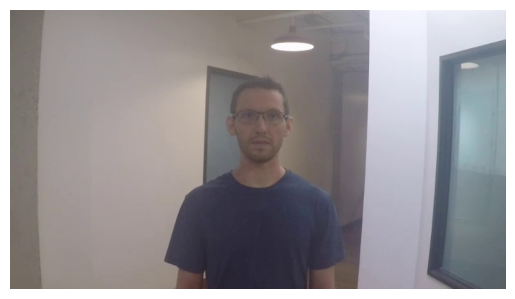

In [5]:
# Cargar un frame del video de demo o una imagen propia
video_path = "/workspace/UrbanEye/sistema_vigilancia/src/videos/face-demographics-walking-and-pause.mp4"
img_path = None  # pon una ruta a imagen si prefieres

if img_path:
    bgr = cv2.imread(img_path)
    assert bgr is not None, f"No se pudo leer imagen: {img_path}"
else:
    cap = cv2.VideoCapture(video_path)
    assert cap.isOpened(), f"No se pudo abrir video: {video_path}"
    ok, bgr = cap.read()
    cap.release()
    assert ok, "No se pudo leer un frame del video"

rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
print("Frame shape:", rgb.shape)

# Mostrar inline (si usas Jupyter local)
try:
    from matplotlib import pyplot as plt
    plt.imshow(rgb)
    plt.axis('off')
    plt.show()
except Exception as e:
    print("matplotlib no disponible:", e)


In [7]:
# Probar DeepFace.analyze con varios backends
backends = ["retinaface", "mtcnn", "opencv"]
all_results = {}
for be in backends:
    try:
        print(f"\n=== Backend: {be} ===")
        res = DeepFace.analyze(
            img_path=rgb,  # RGB
            actions=["age", "gender", "race", "emotion"],
            enforce_detection=False,
            align=True,
            detector_backend=be,
        )
        if isinstance(res, dict):
            res = [res]
        print("num faces:", len(res))
        for i, r in enumerate(res):
            region = r.get("region")
            print(f"face {i}: region={region}")
            print({k: r.get(k) for k in ["age", "dominant_gender", "dominant_race", "dominant_emotion"]})
        all_results[be] = res
    except Exception as e:
        print("error:", e)

all_results



=== Backend: retinaface ===


2025-10-30 20:49:37.603227: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1761857377.603597   17754 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 14449 MB memory:  -> device: 0, name: NVIDIA RTX 2000 Ada Generation, pci bus id: 0000:01:00.0, compute capability: 8.9
2025-10-30 20:49:40.453772: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002
Action: age:   0%|          | 0/4 [00:00<?, ?it/s]    

25-10-30 20:49:44 - 🔗 age_model_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/age_model_weights.h5 to /root/.deepface/weights/age_model_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/age_model_weights.h5
To: /root/.deepface/weights/age_model_weights.h5
100%|██████████| 539M/539M [00:04<00:00, 134MB/s]
Action: gender:  25%|██▌       | 1/4 [00:06<00:18,  6.11s/it]

25-10-30 20:49:50 - 🔗 gender_model_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/gender_model_weights.h5 to /root/.deepface/weights/gender_model_weights.h5...


...

Action: emotion: 100%|██████████| 4/4 [00:00<00:00, 76.80it/s]


num faces: 1
face 0: region={'x': 344, 'y': 127, 'w': 77, 'h': 99, 'left_eye': (406, 163), 'right_eye': (370, 164)}
{'age': 35, 'dominant_gender': 'Man', 'dominant_race': 'white', 'dominant_emotion': 'sad'}

=== Backend: opencv ===


Action: emotion: 100%|██████████| 4/4 [00:00<00:00, 78.53it/s]

num faces: 1
face 0: region={'x': 337, 'y': 127, 'w': 101, 'h': 101, 'left_eye': None, 'right_eye': None}
{'age': 34, 'dominant_gender': 'Man', 'dominant_race': 'white', 'dominant_emotion': 'neutral'}


{'retinaface': [{'age': 34,
   'region': {'x': 347,
    'y': 122,
    'w': 79,
    'h': 109,
    'left_eye': (406, 165),
    'right_eye': (369, 164),
    'nose': (388, 186),
    'mouth_left': (401, 206),
    'mouth_right': (373, 206)},
   'face_confidence': 1.0,
   'gender': {'Woman': 1.228508073836565, 'Man': 98.77150058746338},
   'dominant_gender': 'Man',
   'race': {'asian': 1.3555289513078606e-05,
    'indian': 1.7424966358703387e-05,
    'black': 3.659781144804697e-07,
    'white': 99.87161159515381,
    'middle eastern': 0.06135563016869128,
    'latino hispanic': 0.06699957884848118},
   'dominant_race': 'white',
   'emotion': {'angry': 0.9024680592119694,
    'disgust': 4.349801940861653e-06,
    'fear': 2.176959440112114,
    'happy': 1.143126655369997,
    'sad': 15.310563147068024,
    'surprise': 0.02786120167002082,
    'neutral': 80.43901920318604},
   'dominant_emotion': 'neutral'}],
 'mtcnn': [{'age': 35,
   'region': {'x': 344,
    'y': 127,
    'w': 77,
    'h': 99,


In [ ]:
# Si analyze no devuelve atributos, probar extract_faces y analizar cada recorte con detector "skip"
try:
    faces = DeepFace.extract_faces(img_path=rgb, detector_backend="retinaface", enforce_detection=False, align=True)
except Exception as e:
    print("extract_faces retinaface error:", e)
    try:
        faces = DeepFace.extract_faces(img_path=rgb, detector_backend="mtcnn", enforce_detection=False, align=True)
    except Exception as e2:
        print("extract_faces mtcnn error:", e2)
        faces = []

print("faces extraidas:", len(faces))
attrs_list = []
for i, f in enumerate(faces):
    fa = f.get("face")
    if fa is None:
        continue
    # fa está en RGB 224x224
    try:
        attrs = DeepFace.analyze(
            img_path=fa,
            actions=["age", "gender", "race", "emotion"],
            detector_backend="skip",
            enforce_detection=False,
            align=False,
            prog_bar=False,
        )
        if isinstance(attrs, list):
            attrs = attrs[0] if attrs else {}
    except Exception as e:
        print(f"face {i} analyze error:", e)
        attrs = {}
    attrs_list.append(attrs)

attrs_list


In [ ]:
# Visualizar bounding boxes de extract_faces (si existen)
try:
    import matplotlib.pyplot as plt
    vis = rgb.copy()
    for f in faces:
        area = f.get("facial_area") or {}
        x = int(area.get("x", area.get("left", 0)))
        y = int(area.get("y", area.get("top", 0)))
        w = int(area.get("w", 0)) or int(area.get("width", 0))
        h = int(area.get("h", 0)) or int(area.get("height", 0))
        if w == 0 and "right" in area and "left" in area:
            w = int(area["right"]) - int(area.get("left", 0))
        if h == 0 and "bottom" in area and "top" in area:
            h = int(area["bottom"]) - int(area.get("top", 0))
        if w > 0 and h > 0:
            cv2.rectangle(vis, (x, y), (x+w, y+h), (0,255,0), 2)
    plt.imshow(vis)
    plt.axis('off')
    plt.show()
except Exception as e:
    print("visualización no disponible:", e)
